<a href="https://colab.research.google.com/github/Mansik-04/assignments/blob/main/boosting%20technique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. What is Boosting in Machine Learning?

Boosting is an ensemble technique that combines many weak learners (usually decision trees) sequentially. Each learner focuses more on correcting the errors of the previous ones.

2. How does Boosting differ from Bagging?

Bagging: parallel, reduces variance, trains models independently on bootstrap samples.

Boosting: sequential, reduces bias, later models focus on misclassified/poorly predicted samples.

3. Key idea behind AdaBoost

Increase weights of misclassified samples so the next weak learner focuses on them. Final prediction is a weighted majority vote.

4. Working of AdaBoost (example)

Start with equal weights for all samples.

Train weak learner (e.g., stump).

Increase weights of misclassified samples.

Repeat for many rounds.

Combine learners with weighted voting.

5. Gradient Boosting vs AdaBoost

AdaBoost: reweights samples to focus on misclassified points.

Gradient Boosting: fits new learners to minimize the gradient of the loss function (error residuals).

6. Loss function in Gradient Boosting

Commonly: Squared Error (for regression), Log Loss (for classification).

7. How XGBoost improves over Gradient Boosting

Regularization (L1 & L2).

Parallel training.

Handling missing values.

Better optimization & scalability.

8. Difference between XGBoost and CatBoost

XGBoost: handles numerical & categorical data (needs encoding).

CatBoost: specifically designed for categorical features, uses ordered boosting to reduce overfitting.

9. Real-world applications of Boosting

Fraud detection.

Search engine ranking.

Customer churn prediction.

Medical diagnosis.

Recommendation systems.

10. How regularization helps in XGBoost

Controls model complexity using L1/L2 penalties to avoid overfitting.

11. Hyperparameters to tune in Gradient Boosting

n_estimators

learning_rate

max_depth

min_samples_split

subsample

12. Feature Importance in Boosting

Calculated by:

Total reduction in impurity.

Gain contribution of each feature.

Permutation importance.

13. Why CatBoost is efficient for categorical data

It uses ordered boosting and target statistics encoding, avoiding overfitting and handling categorical features directly without preprocessing.

AdaBoost Accuracy: 0.9649122807017544
AdaBoost MAE: 0.6497879664773323
Gradient Boosting Accuracy: 0.956140350877193
Feature Importances: [1.29234808e-05 2.78045836e-02 2.01183642e-04 4.25403304e-04
 2.46660446e-03 2.99604699e-03 9.22233287e-04 4.50527588e-01
 5.19940461e-04 1.06691601e-04 6.87020789e-03 3.60401381e-03
 1.15680237e-03 8.41527251e-03 5.56452892e-04 2.51063498e-03
 1.30679228e-02 2.03810848e-03 7.02862580e-04 4.22393330e-03
 7.55888752e-02 3.98864800e-02 5.14082111e-02 3.82446946e-02
 4.81083076e-03 4.50121585e-04 1.87249757e-02 2.40103086e-01
 1.47800843e-03 1.75306929e-04]
Gradient Boosting R2: 0.7756446042829697


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [11:21:20] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.956140350877193
Gradient Boosting Accuracy: 0.956140350877193
CatBoost F1 Score: 0.9722222222222222
XGBoost Regressor MSE: 0.2225899267544737


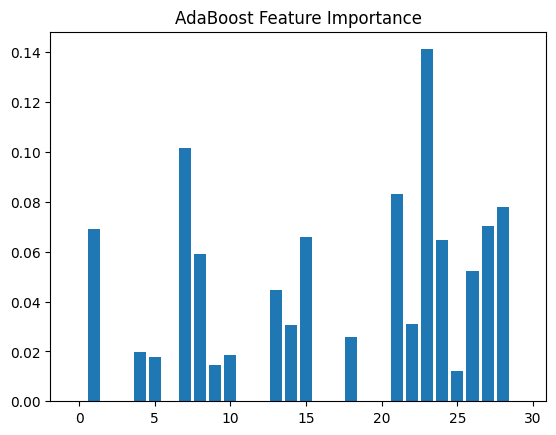

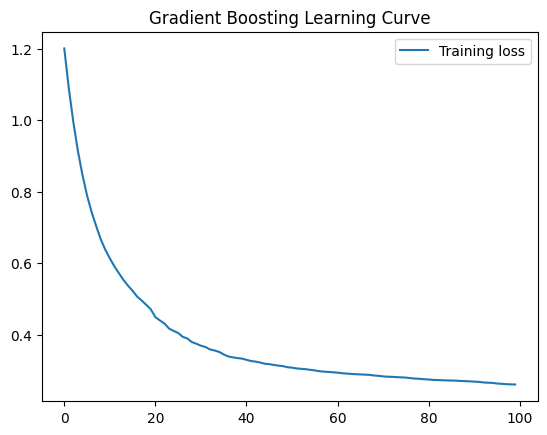

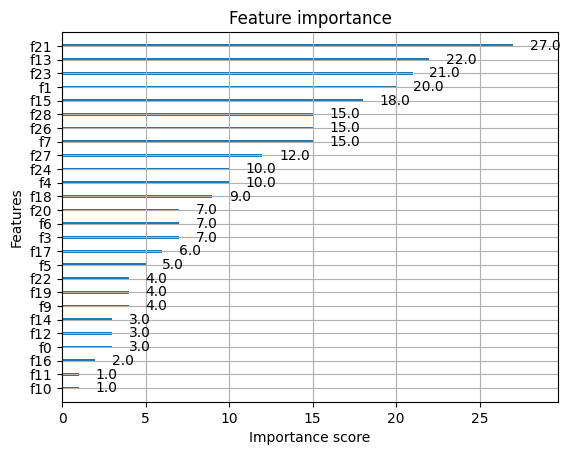

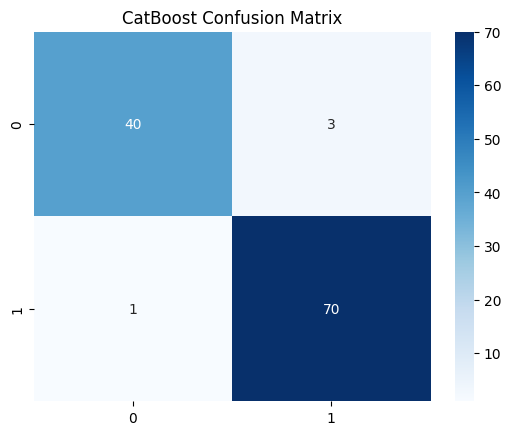

AdaBoost with 10 estimators Accuracy: 0.9649122807017544
AdaBoost with 50 estimators Accuracy: 0.9649122807017544
AdaBoost with 100 estimators Accuracy: 0.9736842105263158


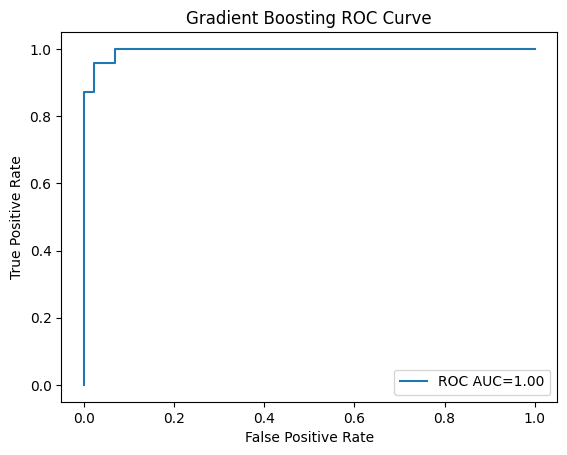

Best Learning Rate: {'learning_rate': 0.2}
CatBoost (with class weights) Accuracy: 0.9666666666666667
AdaBoost (lr=0.01) Accuracy: 0.9385964912280702
AdaBoost (lr=0.1) Accuracy: 0.956140350877193
AdaBoost (lr=1.0) Accuracy: 0.9649122807017544
XGBoost Multiclass Log Loss: 0.30474682595224106


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer, fetch_california_housing, load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score, mean_squared_error, f1_score, confusion_matrix, roc_curve, auc, log_loss
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor, GradientBoostingClassifier, GradientBoostingRegressor

from xgboost import XGBClassifier, XGBRegressor, plot_importance
from catboost import CatBoostClassifier

RANDOM_STATE = 42

# Sample dataset
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=RANDOM_STATE)

# 1. AdaBoost Classifier
ada_clf = AdaBoostClassifier(n_estimators=50, random_state=RANDOM_STATE)
ada_clf.fit(X_train, y_train)
print("AdaBoost Accuracy:", accuracy_score(y_test, ada_clf.predict(X_test)))

# 2. AdaBoost Regressor (California Housing)
house = fetch_california_housing()
Xh, yh = house.data, house.target
Xh_train, Xh_test, yh_train, yh_test = train_test_split(Xh, yh, test_size=0.2, random_state=RANDOM_STATE)
ada_reg = AdaBoostRegressor(n_estimators=100, random_state=RANDOM_STATE)
ada_reg.fit(Xh_train, yh_train)
print("AdaBoost MAE:", mean_absolute_error(yh_test, ada_reg.predict(Xh_test)))

# 3. Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE)
gb_clf.fit(X_train, y_train)
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_clf.predict(X_test)))
print("Feature Importances:", gb_clf.feature_importances_)

# 4. Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE)
gb_reg.fit(Xh_train, yh_train)
print("Gradient Boosting R2:", r2_score(yh_test, gb_reg.predict(Xh_test)))

# 5. XGBoost Classifier vs Gradient Boosting
xgb_clf = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)
xgb_clf.fit(X_train, y_train)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_clf.predict(X_test)))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_clf.predict(X_test)))

# 6. CatBoost Classifier
cat_clf = CatBoostClassifier(iterations=100, verbose=0, random_state=RANDOM_STATE)
cat_clf.fit(X_train, y_train)
y_pred_cat = cat_clf.predict(X_test)
print("CatBoost F1 Score:", f1_score(y_test, y_pred_cat))

# 7. XGBoost Regressor
xgb_reg = XGBRegressor(n_estimators=100, random_state=RANDOM_STATE)
xgb_reg.fit(Xh_train, yh_train)
print("XGBoost Regressor MSE:", mean_squared_error(yh_test, xgb_reg.predict(Xh_test)))

# 8. AdaBoost Feature Importance
plt.bar(range(len(ada_clf.feature_importances_)), ada_clf.feature_importances_)
plt.title("AdaBoost Feature Importance")
plt.show()

# 9. Gradient Boosting Learning Curves
train_score = gb_reg.train_score_
plt.plot(train_score, label='Training loss')
plt.title("Gradient Boosting Learning Curve")
plt.legend()
plt.show()

# 10. XGBoost Feature Importance Plot
plot_importance(xgb_clf)
plt.show()

# 11. CatBoost Confusion Matrix
cm = confusion_matrix(y_test, y_pred_cat)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CatBoost Confusion Matrix")
plt.show()

# 12. AdaBoost with different estimators
for n in [10, 50, 100]:
    ada = AdaBoostClassifier(n_estimators=n, random_state=RANDOM_STATE)
    ada.fit(X_train, y_train)
    print(f"AdaBoost with {n} estimators Accuracy:", accuracy_score(y_test, ada.predict(X_test)))

# 13. Gradient Boosting ROC curve
y_prob = gb_clf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"ROC AUC={roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Gradient Boosting ROC Curve")
plt.legend()
plt.show()

# 14. XGBoost Regressor GridSearchCV (learning rate)
param_grid = {"learning_rate":[0.01, 0.1, 0.2]}
grid = GridSearchCV(XGBRegressor(n_estimators=100, random_state=RANDOM_STATE), param_grid, cv=3)
grid.fit(Xh_train, yh_train)
print("Best Learning Rate:", grid.best_params_)

# 15. CatBoost on imbalanced dataset
iris = load_iris()
Xi, yi = iris.data, iris.target
Xi_train, Xi_test, yi_train, yi_test = train_test_split(Xi, yi, test_size=0.2, random_state=RANDOM_STATE, stratify=yi)
cat_imb = CatBoostClassifier(iterations=100, class_weights=[1,2,2], verbose=0, random_state=RANDOM_STATE)
cat_imb.fit(Xi_train, yi_train)
print("CatBoost (with class weights) Accuracy:", accuracy_score(yi_test, cat_imb.predict(Xi_test)))

# 16. AdaBoost with different learning rates
for lr in [0.01, 0.1, 1.0]:
    ada_lr = AdaBoostClassifier(learning_rate=lr, n_estimators=50, random_state=RANDOM_STATE)
    ada_lr.fit(X_train, y_train)
    print(f"AdaBoost (lr={lr}) Accuracy:", accuracy_score(y_test, ada_lr.predict(X_test)))

# 17. XGBoost Multi-class with log-loss
iris = load_iris()
Xi, yi = iris.data, iris.target
Xi_train, Xi_test, yi_train, yi_test = train_test_split(Xi, yi, test_size=0.2, random_state=RANDOM_STATE, stratify=yi)
xgb_multi = XGBClassifier(objective='multi:softprob', num_class=3, eval_metric='mlogloss', random_state=RANDOM_STATE)
xgb_multi.fit(Xi_train, yi_train)
probs = xgb_multi.predict_proba(Xi_test)
print("XGBoost Multiclass Log Loss:", log_loss(yi_test, probs))


In [2]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.4 MB/s eta 0:00:00
